---

# ⭐ 5가지 실무 미니 케이스

같은 5단계 패턴을 **5가지 다른 실무 상황**에 적용해봅시다.

**케이스마다 바뀌는 건 3가지**:
1. **스키마** (Pydantic 클래스)
2. **프롬프트** (system 메시지)
3. **입력 텍스트**

체인 조립(`prompt | llm | parser`)은 매번 똑같아요. 이 반복을 통해 패턴이 자연스럽게 손에 익습니다.


## 1. 리뷰 분석 확장 — 카테고리 자동 분류




In [ ]:
# 스키마 — 카테고리 + 개선 제안 추가
class ReviewFull(BaseModel):
    rating: int = Field(description="평점 1-5점", ge=1, le=5)
    sentiment: Literal["positive", "negative", "neutral"] = Field(description="감정")
    category: Literal["품질", "가격", "배송", "디자인", "기타"] = Field(description="리뷰가 다루는 영역")
    keywords: list[str] = Field(description="핵심 키워드 3개")
    improvement: Optional[str] = Field(default=None, description="개선 제안 (있으면, 없으면 None)")

parser_r = PydanticOutputParser(pydantic_object=ReviewFull)
prompt_r = ChatPromptTemplate.from_messages([
    ("system", "쇼핑몰 리뷰 분석가입니다. 한국어로 답하세요.\n\n{format_instructions}"),
    ("human", "리뷰: {review}")
]).partial(format_instructions=parser_r.get_format_instructions())

chain_review = prompt_r | llm | parser_r

In [ ]:
# 테스트 — 3개 리뷰
reviews = [
    "포장이 너무 아쉽네요. 박스가 찌그러져 왔어요.",
    "가성비 짱! 이 가격에 이 정도면 최고예요.",
    "디자인은 예쁜데 기능이 좀 부족하네요.",
]

for r in reviews:
    res = chain_review.invoke({"review": r})
    print(f"📝 '{r}'")
    print(f"   ⭐ {res.rating}/5 | {res.sentiment} | 📁 {res.category}")
    print(f"   🏷️  {', '.join(res.keywords)}")
    if res.improvement:
        print(f"   💡 개선: {res.improvement}")
    print()

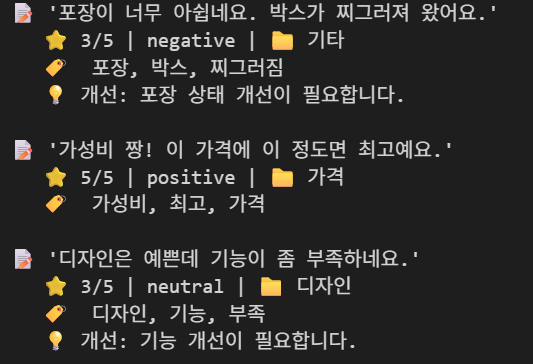

**👀 관찰 포인트**

- 부정 리뷰는 자동으로 `category="배송"` 같이 적절히 분류
- `Optional[str]` 로 만든 `improvement` 필드는 **있을 때만** 채워짐
- `Literal` 로 카테고리를 제한했기 때문에 LLM이 마음대로 새 카테고리를 만들지 못함


## 2 고객 문의 자동 라우팅

고객센터 문의를 **적절한 팀에 자동 배정**하는 시스템

In [ ]:
# 스키마 — 카테고리 + 긴급도 + 담당팀
class InquiryRouting(BaseModel):
    category: Literal["배송", "결제", "환불", "상품문의", "기타"] = Field(description="문의 카테고리")
    urgency: Literal["low", "medium", "high"] = Field(description="긴급도")
    team: Literal["물류팀", "결제팀", "CS팀", "고객지원팀"] = Field(description="담당 팀")
    summary: str = Field(description="문의 한 줄 요약")

parser_i = PydanticOutputParser(pydantic_object=InquiryRouting)
prompt_i = ChatPromptTemplate.from_messages([
    ("system",
     "고객 문의를 적절한 팀에 라우팅합니다.\n"
     "환불 요청·결제 거절·격앙된 톤은 high, 단순 문의는 low로 분류하세요.\n\n"
     "{format_instructions}"),
    ("human", "문의: {inquiry}")
]).partial(format_instructions=parser_i.get_format_instructions())

chain_inquiry = prompt_i | llm | parser_i

In [ ]:
# 테스트 — 5건 문의
inquiries = [
    "어제 주문한 게 아직 안 와요. 빨리 처리해주세요.",
    "카드 결제가 자꾸 거절되네요.",
    "받은 상품이 불량입니다! 당장 환불해주세요!!",
    "이 제품 색상이 사진이랑 다른가요?",
    "주문 취소하고 싶어요.",
]

for q in inquiries:
    res = chain_inquiry.invoke({"inquiry": q})
    icon = {"high": "🚨", "medium": "⚠️", "low": "📌"}[res.urgency]
    print(f"{icon} [{res.category}] → {res.team}")
    print(f"   '{q}'")
    print(f"   요약: {res.summary}")
    print()

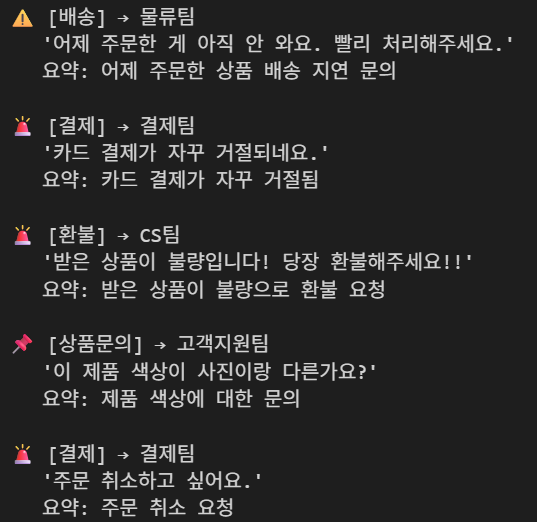

**👀 관찰 포인트**

- "당장!!" 같은 강한 톤 → 자동으로 `high` 우선순위
- LLM이 카테고리·긴급도·담당팀을 **동시에** 결정

실제 콜센터·이커머스가 매일 수만 건 처리하는 핵심 패턴입니다.


## 3 이력서 자동 정보 추출

자연어 이력서에서 **DB 저장용 정형 데이터**를 추출 (이론 5부 사례 3).

여기서는 `Optional` 을 활용해 **있을 수도, 없을 수도 있는 필드**를 표현합니다.


In [ ]:
# 스키마 — Optional 필드 활용
class ResumeInfo(BaseModel):
    name: str = Field(description="이름")
    years_of_experience: int = Field(description="총 경력 연수")
    skills: list[str] = Field(description="기술 스택")
    education: str = Field(description="최종 학력")
    preferred_role: str = Field(description="희망 직무")
    expected_salary: Optional[int] = Field(default=None, description="희망 연봉(만원). 명시 없으면 None")

parser_re = PydanticOutputParser(pydantic_object=ResumeInfo)
prompt_re = ChatPromptTemplate.from_messages([
    ("system", "이력서에서 정보를 추출합니다. 명시되지 않은 항목은 None으로 두세요.\n\n{format_instructions}"),
    ("human", "이력서:\n{resume}")
]).partial(format_instructions=parser_re.get_format_instructions())

chain_resume = prompt_re | llm | parser_re

In [ ]:
# 테스트 — 자연어 이력서
resume_text = """
안녕하세요. 저는 김진환이라고 합니다.
서울대학교 통계학과를 졸업하고 데이터 분석가로 8년째 일하고 있어요.
주로 Python, SQL, Pandas, PyTorch를 사용하며 최근에는 LangChain으로
LLM 애플리케이션도 만들고 있습니다.
다음 직장은 시니어 데이터 사이언티스트로 가고 싶고, 연봉은 7,500만원 정도 희망합니다.
"""

res = chain_resume.invoke({"resume": resume_text})
print(f"👤 이름: {res.name}")
print(f"💼 경력: {res.years_of_experience}년")
print(f"🛠  기술: {', '.join(res.skills)}")
print(f"🎓 학력: {res.education}")
print(f"🎯 희망 직무: {res.preferred_role}")
print(f"💰 희망 연봉: {res.expected_salary}만원")

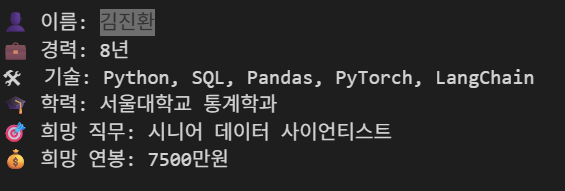

**👀 관찰 포인트**

- 자연어로 쓰인 이력서가 **DB에 바로 저장 가능한 형태**로 변환
- `list[str]` 로 기술 스택이 자동 리스트화 → 검색·필터링 가능

HR 시스템에서 매우 자주 쓰이는 패턴이에요.

> 💡 **시도해보기**: 위 이력서 텍스트에서 "연봉은 7,500만원" 부분을 지우고 다시 실행해보세요. `expected_salary` 가 `None` 으로 나옵니다.
`

## 4. 뉴스 기사 다중 태깅

뉴스 기사에 **여러 개의 카테고리 태그**를 자동 부여하는 사례.

이전 케이스들은 카테고리를 하나만 골랐지만, 여기서는 **`list[Literal[...]]`** 로 여러 개를 동시에 선택합니다.


In [ ]:
# 스키마 — 다중 태그
class NewsAnalysis(BaseModel):
    title: str = Field(description="기사의 짧은 제목 (15자 이내)")
    topics: list[Literal["정치", "경제", "사회", "기술", "문화", "스포츠", "건강", "환경"]] = Field(
        description="해당하는 모든 주제 태그 (복수 선택)"
    )
    importance: Literal[1, 2, 3, 4, 5] = Field(description="중요도 1-5")
    one_line: str = Field(description="기사 한 줄 요약")

parser_n = PydanticOutputParser(pydantic_object=NewsAnalysis)
prompt_n = ChatPromptTemplate.from_messages([
    ("system", "뉴스 기사를 분석하고 적절한 태그를 부여합니다. 한국어로 답하세요.\n\n{format_instructions}"),
    ("human", "기사:\n{article}")
]).partial(format_instructions=parser_n.get_format_instructions())

chain_news = prompt_n | llm | parser_n

In [ ]:
# 테스트 — 복합 주제의 뉴스
articles = [
    "정부가 AI 산업 육성을 위해 5조 원 규모 지원금을 편성했다. "
    "한국의 글로벌 기술 경쟁력 강화를 위한 정책으로, 관련 스타트업과 연구 기관들이 수혜를 받게 된다.",

    "프로야구 한국시리즈에서 LG 트윈스가 우승을 차지했다. "
    "30년 만의 우승에 시민들의 환호가 이어졌다.",

    "전 세계적으로 폭염이 지속되며 농작물 피해가 심각하다. "
    "농가는 정부 지원을 호소하고 있고, 식료품 가격 인상도 우려된다.",
]

for a in articles:
    res = chain_news.invoke({"article": a})
    stars = "⭐" * res.importance
    print(f"📰 {res.title}  {stars}")
    print(f"   태그: {', '.join(res.topics)}")
    print(f"   요약: {res.one_line}")
    print()

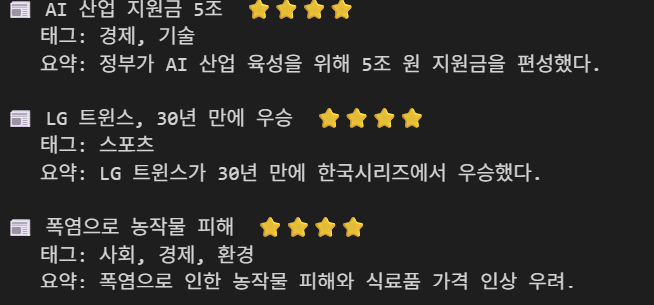

**👀 관찰 포인트**

- 첫 기사는 `["정치", "경제", "기술"]` 같이 **여러 태그 동시 부여**
- 폭염 기사는 `["환경", "사회", "경제"]` 등 복합 주제 인식
- `list[Literal[...]]` 패턴의 강력함

검색엔진 자동 분류, 추천 시스템의 컨텐츠 태깅에 자주 사용됩니다.


## 5 이메일 우선순위 자동 판단

매일 들어오는 이메일을 **자동 분류**하고 **답장 필요 여부**를 판단 (이론 5부 사례 4).

여기서는 **`bool` 필드**로 "답장 필요? Yes/No" 를 받습니다.


In [ ]:
# 스키마 — bool 필드 활용
class EmailTriage(BaseModel):
    category: Literal["업무", "개인", "광고", "스팸"] = Field(description="이메일 카테고리")
    priority: Literal["low", "medium", "high"] = Field(description="우선순위")
    requires_reply: bool = Field(description="답장이 필요한 메일인지")
    suggested_action: Literal["즉시 답장", "오늘 중 답장", "보관", "삭제"] = Field(description="추천 액션")
    one_line: str = Field(description="한 줄 요약")

parser_e = PydanticOutputParser(pydantic_object=EmailTriage)
prompt_e = ChatPromptTemplate.from_messages([
    ("system",
     "이메일을 분류하고 처리 방법을 제안합니다.\n"
     "광고·스팸은 답장 불필요, 업무 메일은 보통 답장 필요로 분류하세요.\n\n"
     "{format_instructions}"),
    ("human", "제목: {subject}\n본문: {body}")
]).partial(format_instructions=parser_e.get_format_instructions())

chain_email = prompt_e | llm | parser_e

In [ ]:
# 테스트 — 다양한 이메일
emails = [
    {"subject": "[긴급] 내일 오전 회의 자료 검토 부탁드립니다",
     "body": "안녕하세요, 내일 10시 회의 자료입니다. 검토 후 의견 부탁드려요."},

    {"subject": "🎉 50% 특가! 오늘만 할인",
     "body": "지금 구매하세요! 한정 수량으로 진행되는 깜짝 세일입니다."},

    {"subject": "면접 일정 확정 안내",
     "body": "선생님, 다음 주 화요일 오후 2시 면접 일정 확정되었습니다. 회신 부탁드립니다."},

    {"subject": "회식 일정 안내",
     "body": "이번 주 금요일 저녁 7시 회식 있습니다. 참석 여부 알려주세요."},
]

for e in emails:
    res = chain_email.invoke({"subject": e["subject"], "body": e["body"]})
    reply_mark = "📬 답장 필요" if res.requires_reply else "📭 답장 불필요"
    icon = {"high": "🔴", "medium": "🟡", "low": "🟢"}[res.priority]
    print(f"{icon} [{res.category}] {res.suggested_action}")
    print(f"   제목: {e['subject']}")
    print(f"   {reply_mark}  |  {res.one_line}")
    print()

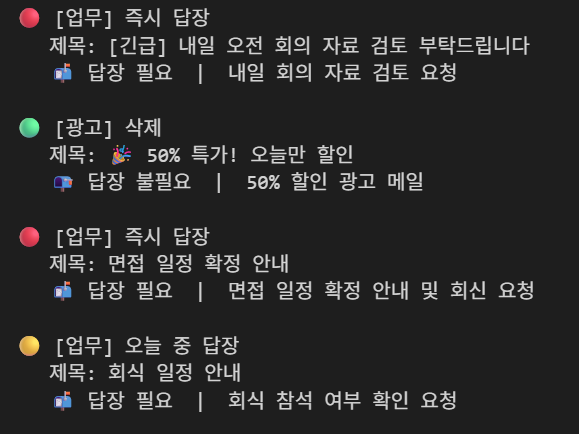

**👀 관찰 포인트**

- 광고 메일 → 자동으로 `requires_reply=False`, `suggested_action="삭제"`
- 회의 요청 → `requires_reply=True`, `priority="high"`
- `bool` 필드로 LLM의 판단을 **참/거짓 형태**로 받음

Gmail, Outlook 같은 메일 서비스가 내부적으로 사용하는 패턴입니다.
